In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Tuesday' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/Tuesday-WorkingHours.pcap_ISCX.csv


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Tuesday-WorkingHours.pcap_ISCX.csv')


print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nLabel counts:")
print(df[' Label'].value_counts())

Shape: (445909, 79)

Columns: [' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag Count', ' PSH Flag Count', 

In [4]:
import numpy as np

df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print("After cleaning:")
print("Shape:", df.shape)
print("\nLabel counts:")
print(df['Label'].value_counts())
print("\nBrute Force %:", round(df['Label'].sum() / len(df) * 100, 2), "%")

After cleaning:
Shape: (445645, 79)

Label counts:
Label
0    431813
1     13832
Name: count, dtype: int64

Brute Force %: 3.1 %


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Training set size: (356516, 78)
Test set size: (89129, 78)

Training label distribution:
Label
0    345450
1     11066
Name: count, dtype: int64

Test label distribution:
Label
0    86363
1     2766
Name: count, dtype: int64


In [6]:
from sklearn.ensemble import RandomForestClassifier
import time

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training started...")
start = time.time()
model.fit(X_train, y_train)
end = time.time()

print("Training complete!")
print("Time taken:", round(end - start, 2), "seconds")

Training started...
Training complete!
Time taken: 51.4 seconds


In [9]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_score, recall_score, f1_score)

y_pred = model.predict(X_test)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fp = sum((y_pred == 1) & (y_test == 0))
tn = sum((y_pred == 0) & (y_test == 0))
fpr = round(fp / (fp + tn) * 100, 4)

print("=" * 50)
print("MODEL PERFORMANCE RESULTS")
print("=" * 50)
print(f"Precision:         {round(precision*100, 2)}%")
print(f"Recall:            {round(recall*100, 2)}%")
print(f"F1-Score:          {round(f1*100, 2)}%")
print(f"False Positive Rate: {fpr}%")
print("=" * 50)
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Brute Force']))

MODEL PERFORMANCE RESULTS
Precision:         100.0%
Recall:            99.93%
F1-Score:          99.96%
False Positive Rate: 0.0%

Detailed Report:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     86363
 Brute Force       1.00      1.00      1.00      2766

    accuracy                           1.00     89129
   macro avg       1.00      1.00      1.00     89129
weighted avg       1.00      1.00      1.00     89129



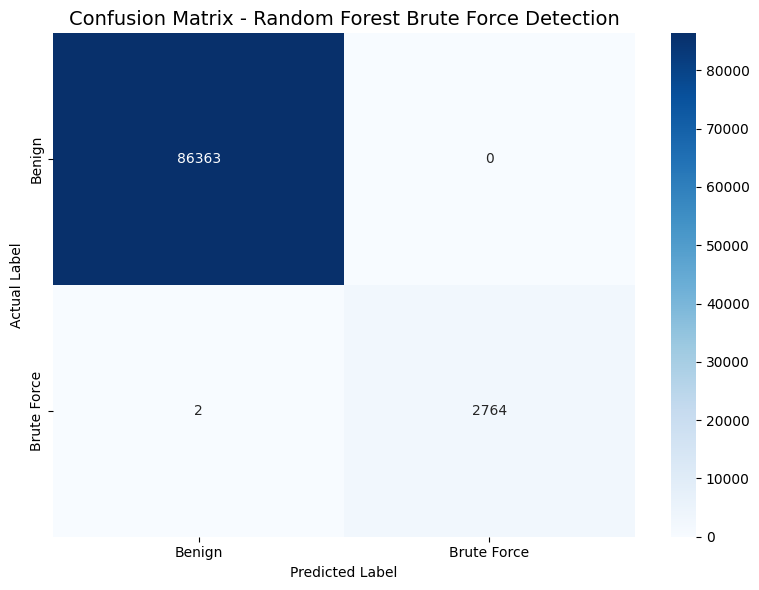

Saved as confusion_matrix.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Brute Force'],
            yticklabels=['Benign', 'Brute Force'])
plt.title('Confusion Matrix - Random Forest Brute Force Detection', fontsize=14)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Saved as confusion_matrix.png")

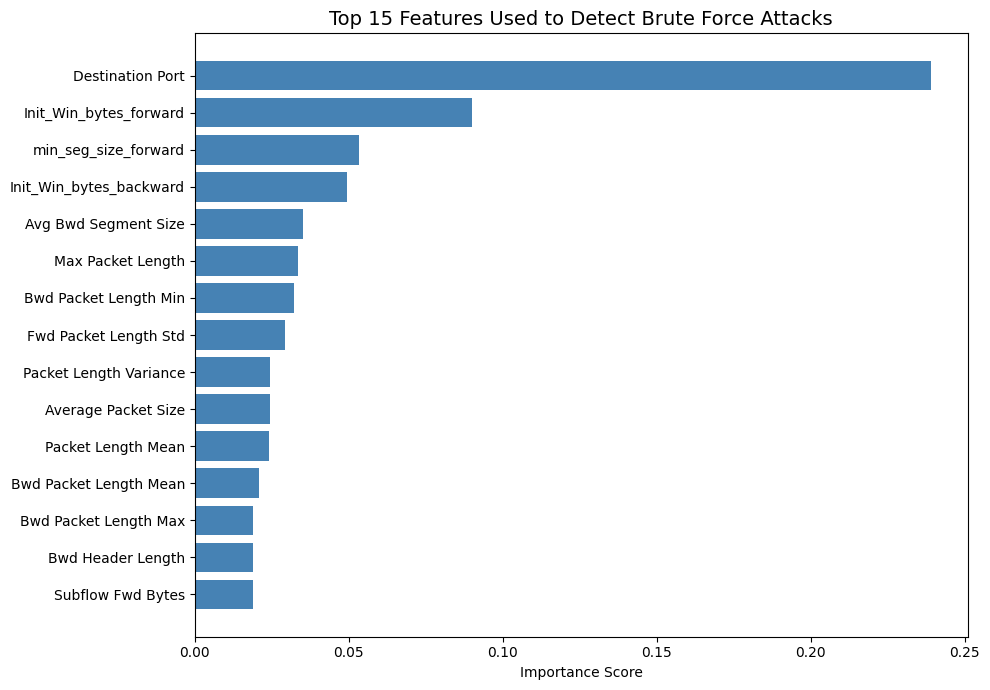

Saved as feature_importance.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
plt.barh(feature_importance['Feature'][::-1],
         feature_importance['Importance'][::-1],
         color='steelblue')
plt.title('Top 15 Features Used to Detect Brute Force Attacks', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Saved as feature_importance.png")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score


threshold = 100
y_rule = (X_test['Flow Packets/s'] > threshold).astype(int)

rule_precision = precision_score(y_test, y_rule, zero_division=0)
rule_recall = recall_score(y_test, y_rule, zero_division=0)
rule_f1 = f1_score(y_test, y_rule, zero_division=0)
rule_fp = sum((y_rule == 1) & (y_test == 0))
rule_tn = sum((y_rule == 0) & (y_test == 0))
rule_fpr = round(rule_fp / (rule_fp + rule_tn) * 100, 2)

ml_precision = precision_score(y_test, y_pred)
ml_recall = recall_score(y_test, y_pred)
ml_f1 = f1_score(y_test, y_pred)
ml_fp = sum((y_pred == 1) & (y_test == 0))
ml_tn = sum((y_pred == 0) & (y_test == 0))
ml_fpr = round(ml_fp / (ml_fp + ml_tn) * 100, 4)

print("=" * 65)
print(f"{'METRIC':<30} {'RULE-BASED':>15} {'ML MODEL':>15}")
print("=" * 65)
print(f"{'Precision':<30} {round(rule_precision*100,2):>14}% {round(ml_precision*100,2):>14}%")
print(f"{'Recall':<30} {round(rule_recall*100,2):>14}% {round(ml_recall*100,2):>14}%")
print(f"{'F1-Score':<30} {round(rule_f1*100,2):>14}% {round(ml_f1*100,2):>14}%")
print(f"{'False Positive Rate':<30} {rule_fpr:>14}% {ml_fpr:>14}%")
print("=" * 65)
print(f"\nRule-Based False Positives:  {rule_fp}")
print(f"ML Model False Positives:    {ml_fp}")
print(f"\nFalse Positive Reduction:    {rule_fp - ml_fp} fewer false alarms")

METRIC                              RULE-BASED        ML MODEL
Precision                                3.05%          100.0%
Recall                                   50.4%          99.93%
F1-Score                                 5.76%          99.96%
False Positive Rate                     51.27%            0.0%

Rule-Based False Positives:  44278
ML Model False Positives:    0

False Positive Reduction:    44278 fewer false alarms


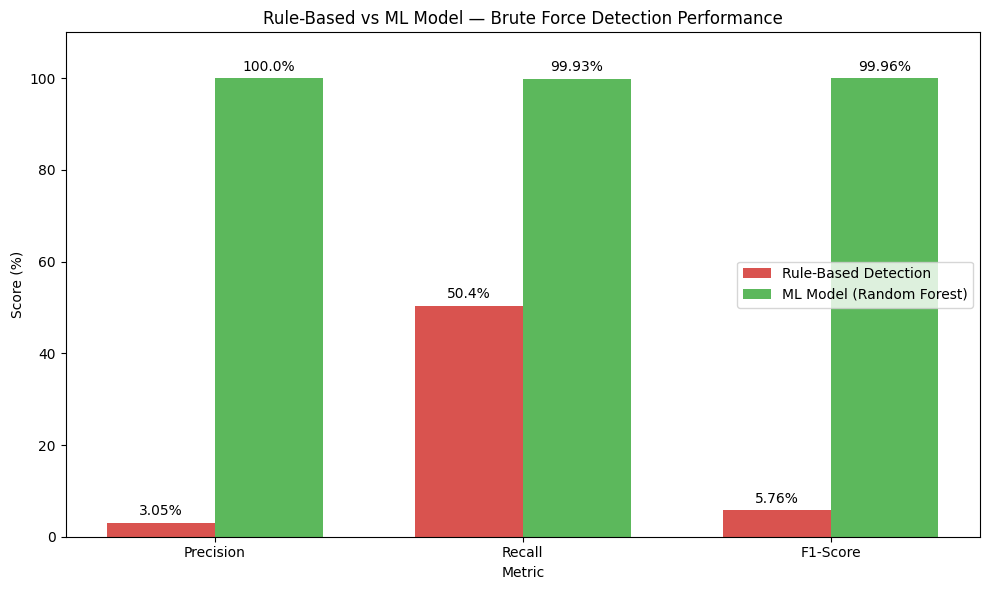

Saved as comparison_chart.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Precision', 'Recall', 'F1-Score']
rule_scores = [3.05, 50.4, 5.76]
ml_scores = [100.0, 99.93, 99.96]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, rule_scores, width,
               label='Rule-Based Detection', color='#d9534f')
bars2 = ax.bar(x + width/2, ml_scores, width,
               label='ML Model (Random Forest)', color='#5cb85c')

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Rule-Based vs ML Model — Brute Force Detection Performance')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 110)
ax.legend()


for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{bar.get_height()}%', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
            f'{bar.get_height()}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150)
plt.show()
print("Saved as comparison_chart.png")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

models = {
    'Random Forest':      RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1),
    'XGBoost':            XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
    'Decision Tree':      DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Logistic Regression':  LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, n_jobs=-1),
    'Linear SVM':           LinearSVC(class_weight='balanced', max_iter=1000, random_state=42),
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    start = time.time()
    model.fit(X_train, y_train)
    train_time = round(time.time() - start, 2)

    y_pred_model = model.predict(X_test)

    precision = round(precision_score(y_test, y_pred_model, zero_division=0) * 100, 2)
    recall    = round(recall_score(y_test, y_pred_model, zero_division=0) * 100, 2)
    f1        = round(f1_score(y_test, y_pred_model, zero_division=0) * 100, 2)
    fp        = int(sum((y_pred_model == 1) & (y_test == 0)))
    tn        = int(sum((y_pred_model == 0) & (y_test == 0)))
    fpr       = round(fp / (fp + tn) * 100, 2) if (fp + tn) > 0 else 0

    results.append({
        'Model': name,
        'Precision %': precision,
        'Recall %': recall,
        'F1-Score %': f1,
        'False Positive Rate %': fpr,
        'False Positives': fp,
        'Train Time (s)': train_time
    })
    print(f"  Done — F1: {f1}% | FPR: {fpr}% | Time: {train_time}s")

print("\nAll models trained.")

Training Random Forest...
  Done — F1: 99.96% | FPR: 0.0% | Time: 50.66s
Training XGBoost...
  Done — F1: 99.98% | FPR: 0.0% | Time: 18.42s
Training Decision Tree...
  Done — F1: 99.89% | FPR: 0.0% | Time: 4.34s
Training K-Nearest Neighbours...
  Done — F1: 98.33% | FPR: 0.07% | Time: 0.23s
Training Logistic Regression...
  Done — F1: 70.55% | FPR: 2.53% | Time: 107.01s
Training Linear SVM...
  Done — F1: 75.46% | FPR: 2.06% | Time: 366.95s

All models trained.
